In [1]:
# Ambiente: esta é a única célula que muda entre Jupyter local e Colab.
from pathlib import Path
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/AMMCI_PRF")  # Ajuste sua pasta aqui.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scipy>=1.14,<2"], check=True)
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print("Dados:", DATA_DIR)
print("Figuras:", FIGURE_DIR)

Dados: d:\Workspace\ws-uem\acidentes-rodoviarios-ml\data
Figuras: d:\Workspace\ws-uem\acidentes-rodoviarios-ml\outputs\figures


# 02 — Análise de drift

## Objetivo

Comparar as distribuições de D0, D1 e D2.

Os splits do notebook 01 são reutilizados sem alterações.

As figuras são salvas em `outputs/figures/drift_*.png`.

Mudanças marginais em X ou y indicam **data drift**, mas não confirmam **concept drift**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import ks_2samp, chi2_contingency
from IPython.display import display

NUMERIC = ["hora", "mes", "km", "latitude", "longitude", "veiculos"]
CATEGORICAL = [
    "dia_semana", "uf", "br", "causa_acidente", "tipo_acidente",
    "fase_dia", "sentido_via", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo",
]
TARGET = "classificacao_acidente"
COLORS = {"d0": "#337a98", "d1": "#dc9b33", "d2": "#ba3b46"}
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

assert len(CATEGORICAL) == 11, "A análise deve cobrir as 11 variáveis categóricas do modelo."


## 1. Carregar os splits já definidos

São verificados período, ordem temporal e IDs compartilhados entre splits.

In [3]:
# Reutiliza exatamente os splits temporais definidos no notebook 01.
splits = {}
for name in ["d0", "d1", "d2"]:
    part = pd.read_csv(DATA_DIR / f"{name}.csv", sep=";", encoding="utf-8",
                       dtype={"br": "string"}, parse_dates=["timestamp"])
    assert not part.empty and part.timestamp.notna().all(), f"Revisar {name}."
    assert part.timestamp.is_monotonic_increasing, f"{name} não está ordenado."
    assert part[TARGET].notna().all() and part.id.notna().all(), f"Revisar alvo/ID em {name}."
    assert not part.id.duplicated().any(), f"IDs duplicados em {name}."
    splits[name] = part
d0, d1, d2 = splits.values()
assert d0.timestamp.max() <= d1.timestamp.min() and d1.timestamp.max() <= d2.timestamp.min()
assert set(d0.id).isdisjoint(d1.id) and set(d0.id).isdisjoint(d2.id) and set(d1.id).isdisjoint(d2.id)
display(pd.DataFrame([{"split": name, "registros": len(part),
                       "início": part.timestamp.min(), "fim": part.timestamp.max()}
                      for name, part in splits.items()]))
missing = pd.DataFrame({name: part[NUMERIC + CATEGORICAL + [TARGET]].isna().sum()
                        for name, part in splits.items()})
display(missing)
assert missing.to_numpy().sum() == 0, "Surgiram ausentes: revisar antes de comparar, sem exclusão silenciosa."
assert all(np.isfinite(part[NUMERIC].to_numpy()).all() for part in splits.values())

,split,registros,início,fim
0,d0,87838,2023-01-01 00:01:00,2024-04-17 07:50:00
1,d1,29279,2024-04-17 07:50:00,2024-09-08 15:30:00
2,d2,29280,2024-09-08 15:30:00,2025-01-31 23:30:00


,d0,d1,d2
hora,0,0,0
mes,0,0,0
km,0,0,0
latitude,0,0,0
longitude,0,0,0
veiculos,0,0,0
dia_semana,0,0,0
uf,0,0,0
br,0,0,0
causa_acidente,0,0,0


## 2. Distribuições numéricas

Estatísticas descritivas e curvas ECDF comparam as variáveis numéricas entre os três splits.

count     mean      std     min     25%      50%      75%  \
split variável                                                                 
d0    hora       87838.0   12.889    6.057   0.000   8.000   14.000   18.000   
      mes        87838.0    5.681    3.571   1.000   3.000    5.000    9.000   
      km         87838.0  260.054  226.529   0.000  77.000  196.200  407.400   
      latitude   87838.0  -18.944    7.683 -33.619 -25.164  -20.476  -12.845   
      longitude  87838.0  -46.482    6.145 -70.557 -50.248  -47.383  -42.413   
      veiculos   87838.0    1.989    1.180   1.000   1.000    2.000    2.000   
d1    hora       29279.0   12.928    6.057   0.000   8.000   14.000   18.000   
      mes        29279.0    6.399    1.402   4.000   5.000    6.000    8.000   
      km         29279.0  257.124  227.344   0.000  75.000  189.000  401.000   
      latitude   29279.0  -18.730    7.724 -33.681 -25.059  -20.338  -12.463   
      longitude  29279.0  -46.460    6.276 -70.771 -50.381  -47.219  -42.186   
      veiculos   29279.0    2.021    1.116   1.000   1.000    2.000    2.000   
d2    hora       29280.0   12.951    6.022   0.000   8.000   14.000   18.000   
      mes        29280.0    8.816    3.876   1.000   9.000   10.000   11.000   
      km         29280.0  258.635  228.460   0.000  74.500  190.000  407.000   
      latitude   29280.0  -18.818    7.733 -33.514 -25.103  -20.465  -12.602   
      longitude  29280.0  -46.305    6.188 -72.642 -50.037  -46.644  -42.147   
      veiculos   29280.0    1.964    1.070   1.000   1.000    2.000    2.000   

                      max  
split variável             
d0    hora         23.000  
      mes          12.000  
      km         1258.000  
      latitude      4.476  
      longitude   -34.828  
      veiculos    131.000  
d1    hora         23.000  
      mes           9.000  
      km         1252.000  
      latitude      4.215  
      longitude   -32.407  
      veiculos     20.000  
d2    hora         23.000  
      mes          12.000  
      km         1470.000  
      latitude      4.461  
      longitude   -34.828  
      veiculos     26.000

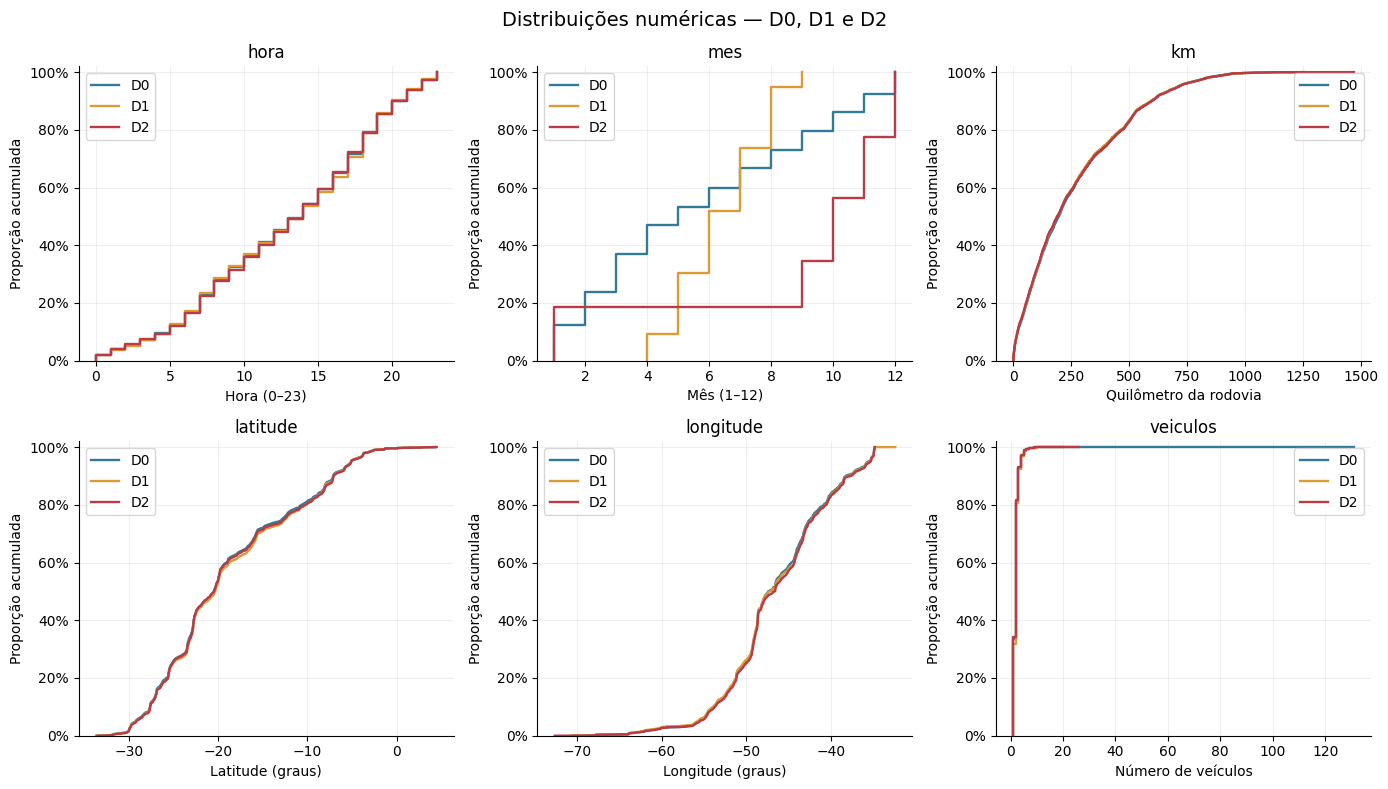

In [4]:
descriptive = pd.concat({name: part[NUMERIC].describe(percentiles=[0.25, 0.5, 0.75]).T
                        for name, part in splits.items()}, names=["split", "variável"])
display(descriptive.round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
units = {"hora": "Hora (0–23)", "mes": "Mês (1–12)", "km": "Quilômetro da rodovia",
         "latitude": "Latitude (graus)", "longitude": "Longitude (graus)", "veiculos": "Número de veículos"}
for column, ax in zip(NUMERIC, axes.flat):
    for name, part in splits.items():
        values = part[column].value_counts().sort_index()
        cumulative = values.cumsum() / len(part)
        x = np.r_[values.index[0], values.index.to_numpy()]
        y = np.r_[0, cumulative.to_numpy()]
        ax.step(x, y, where="post", label=name.upper(), color=COLORS[name], linewidth=1.7)
    ax.set(title=column, xlabel=units[column], ylabel="Proporção acumulada", ylim=(0, 1.02))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle("Distribuições numéricas — D0, D1 e D2", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "drift_numeric_ecdf.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Teste de Kolmogorov–Smirnov (KS)

A estatística **D** do teste KS mede a distância entre duas distribuições.

A interpretação prioriza D e os gráficos, pois amostras grandes produzem p-valores baixos mesmo para diferenças pequenas.

Os p-valores são exploratórios: há variáveis discretas, empates e dependência temporal e espacial.

Referência: [SciPy — ks_2samp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html).

`0.000e+00` representa arredondamento numérico, não probabilidade zero.

,variável,comparação,D_KS,p_aproximado,observação
0,hora,D0 → D1,0.0137,5.214e-04,Discreta: p apenas exploratório
1,hora,D0 → D2,0.0091,5.125e-02,Discreta: p apenas exploratório
2,mes,D0 → D1,0.3759,0.000e+00,Discreta: p apenas exploratório
3,mes,D0 → D2,0.5442,0.000e+00,Discreta: p apenas exploratório
4,km,D0 → D1,0.0109,1.075e-02,Empates e dependência podem afetar p
5,km,D0 → D2,0.0131,1.078e-03,Empates e dependência podem afetar p
6,latitude,D0 → D1,0.0172,4.305e-06,Empates e dependência podem afetar p
7,latitude,D0 → D2,0.0101,2.283e-02,Empates e dependência podem afetar p
8,longitude,D0 → D1,0.0134,7.415e-04,Empates e dependência podem afetar p
9,longitude,D0 → D2,0.0198,6.071e-08,Empates e dependência podem afetar p


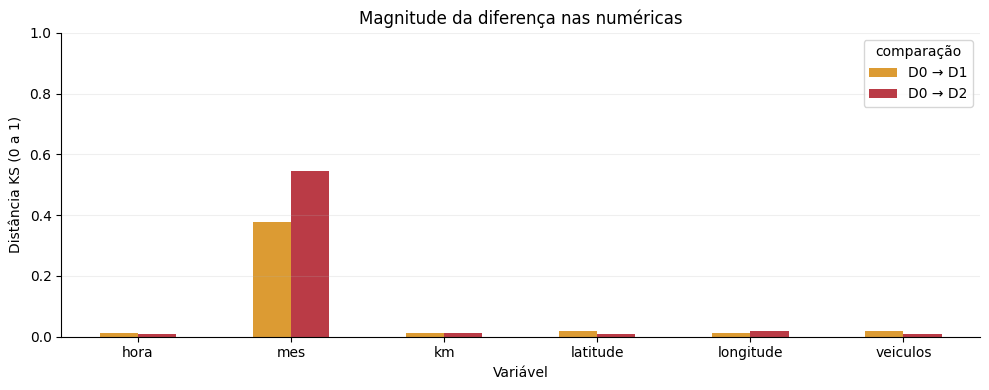

In [5]:
# A estatística D representa magnitude; o p-valor é evidência complementar.
ks_rows = []
for column in NUMERIC:
    for recent in ["d1", "d2"]:
        result = ks_2samp(d0[column], splits[recent][column], alternative="two-sided", method="asymp")
        ks_rows.append({"variável": column, "comparação": f"D0 → {recent.upper()}",
                        "D_KS": result.statistic, "p_aproximado": result.pvalue,
                        "observação": "Discreta: p apenas exploratório" if column in ["hora", "mes", "veiculos"]
                        else "Empates e dependência podem afetar p"})
ks_results = pd.DataFrame(ks_rows)
display(ks_results.style.format({"D_KS": "{:.4f}", "p_aproximado": "{:.3e}"}))

fig, ax = plt.subplots(figsize=(10, 4))
ks_results.pivot(index="variável", columns="comparação", values="D_KS").reindex(NUMERIC).plot.bar(
    ax=ax, color=[COLORS["d1"], COLORS["d2"]], rot=0)
ax.set(title="Magnitude da diferença nas numéricas", xlabel="Variável", ylabel="Distância KS (0 a 1)", ylim=(0, 1))
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "drift_numeric_ks.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Proporções das categorias

Os gráficos comparam as 11 variáveis categóricas do modelo. Categorias menos frequentes são agrupadas como “Outros” apenas na visualização.

Os testes usam todas as categorias originais.



dia_semana: proporções (%) das principais categorias de D0


,d0,d1,d2
dia_semana,,,
domingo,16.39,16.21,15.89
sábado,16.14,16.32,15.52
sexta-feira,15.18,15.98,15.63
segunda-feira,13.92,13.45,13.76
quinta-feira,13.05,13.31,13.43
quarta-feira,12.70,12.78,13.08
terça-feira,12.61,11.94,12.69


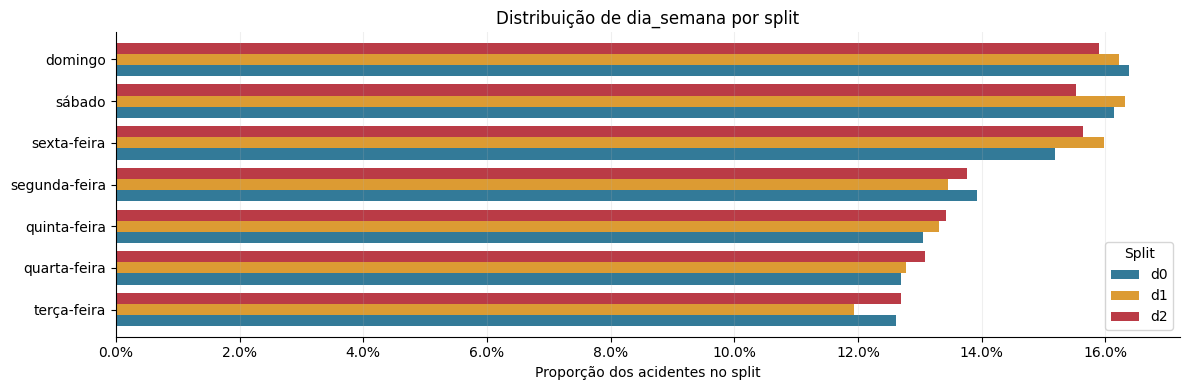


uf: proporções (%) das principais categorias de D0


,d0,d1,d2
uf,,,
MG,13.23,12.25,13.12
SC,11.62,11.23,11.26
PR,10.40,10.40,10.61
RJ,8.27,8.76,8.97
RS,7.30,7.07,7.04
SP,6.97,6.50,6.70
BA,5.54,5.86,5.60
GO,4.60,4.73,4.25
PE,4.45,4.47,4.19


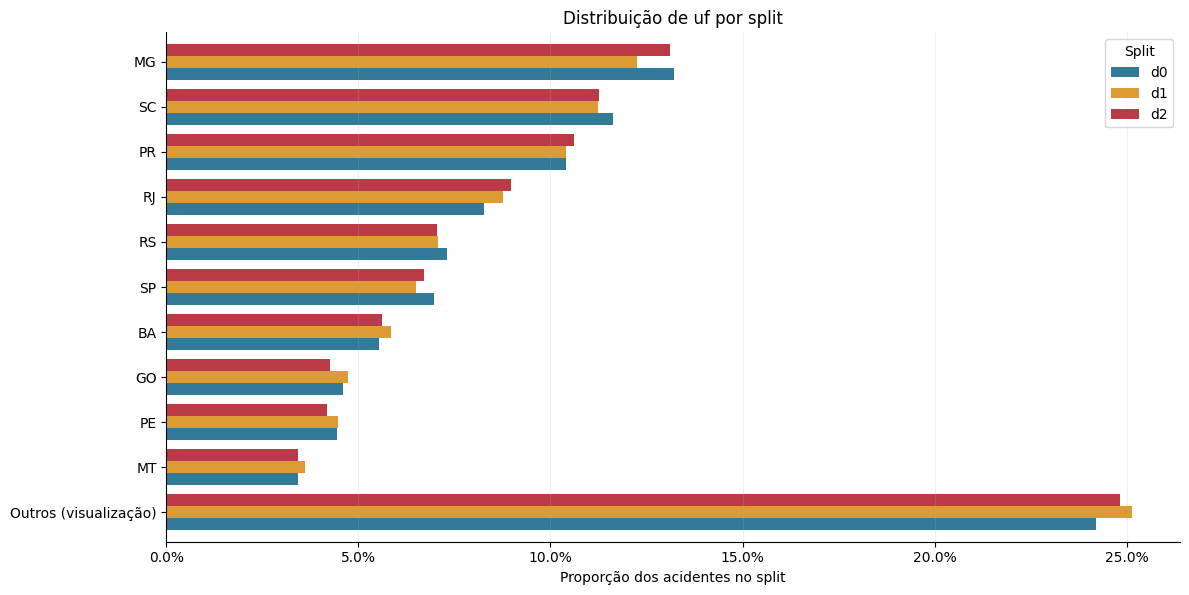


br: proporções (%) das principais categorias de D0


,d0,d1,d2
br,,,
101,17.46,17.01,17.42
116,15.83,15.65,15.82
381,4.85,4.42,4.99
40,4.75,4.74,4.45
153,3.74,3.83,3.73
163,3.35,3.66,3.38
364,3.04,3.17,2.93
277,2.89,2.89,2.82
376,2.56,2.35,2.61


Categorias presentes em D1/D2, ausentes em D0 (contagens):


,d0,d1,d2
br,,,
307,0,0,1
363,0,1,0
466,0,1,0


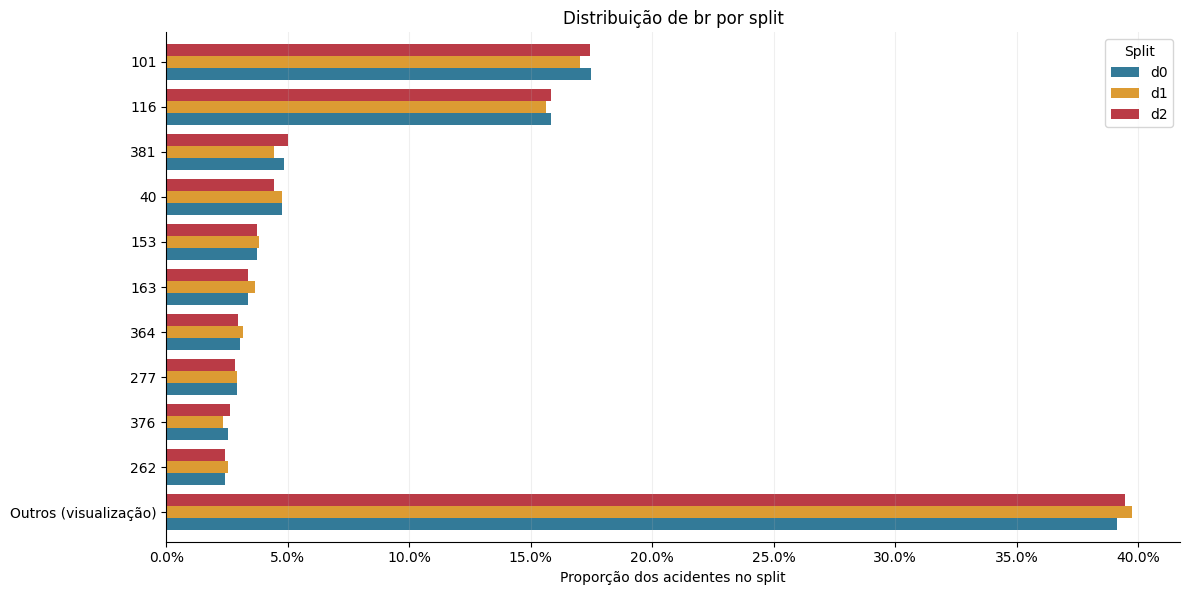


causa_acidente: proporções (%) das principais categorias de D0


,d0,d1,d2
causa_acidente,,,
Reação tardia ou ineficiente do condutor,14.64,15.08,14.72
Ausência de reação do condutor,13.84,14.85,14.66
Acessar a via sem observar a presença dos outros veículos,9.23,10.06,9.34
Condutor deixou de manter distância do veículo da frente,6.25,6.22,6.00
Velocidade Incompatível,6.21,5.45,6.57
Manobra de mudança de faixa,5.80,5.75,5.52
Ingestão de álcool pelo condutor,5.26,5.41,5.10
Demais falhas mecânicas ou elétricas,4.42,4.68,4.59
Transitar na contramão,3.43,3.51,3.26


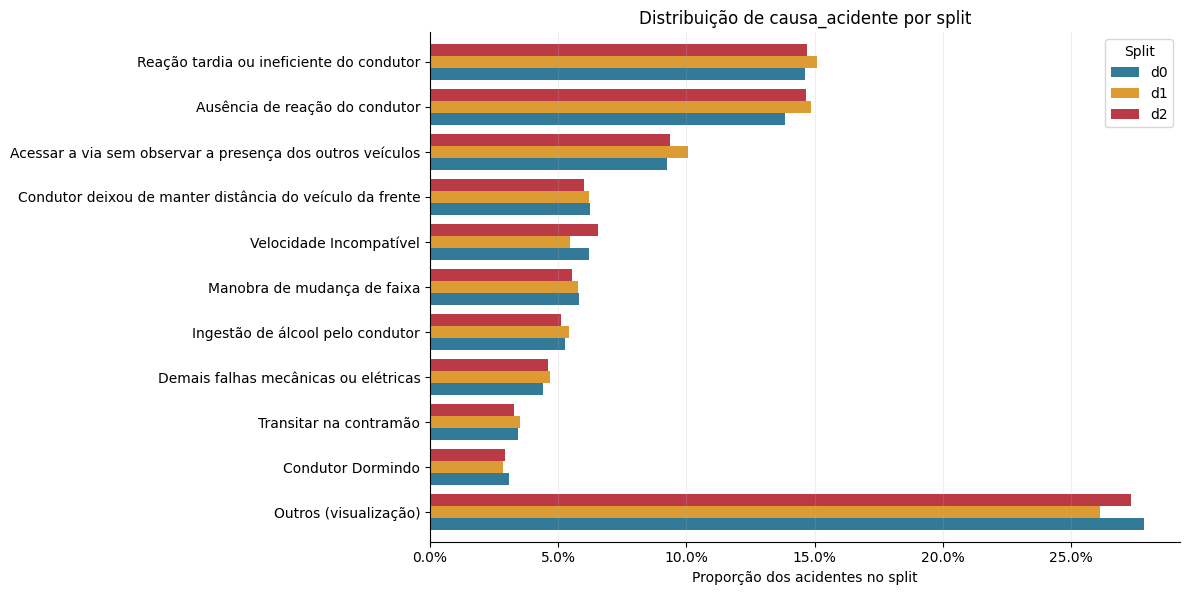


tipo_acidente: proporções (%) das principais categorias de D0


,d0,d1,d2
tipo_acidente,,,
Colisão traseira,18.98,19.65,18.75
Saída de leito carroçável,15.21,13.80,15.48
Colisão transversal,12.43,13.24,12.90
Colisão lateral mesmo sentido,10.40,10.95,10.70
Tombamento,8.57,8.62,8.81
Colisão com objeto,7.22,6.60,7.31
Colisão frontal,6.79,6.54,6.66
Queda de ocupante de veículo,4.60,4.53,4.52
Atropelamento de Pedestre,4.51,4.57,4.13


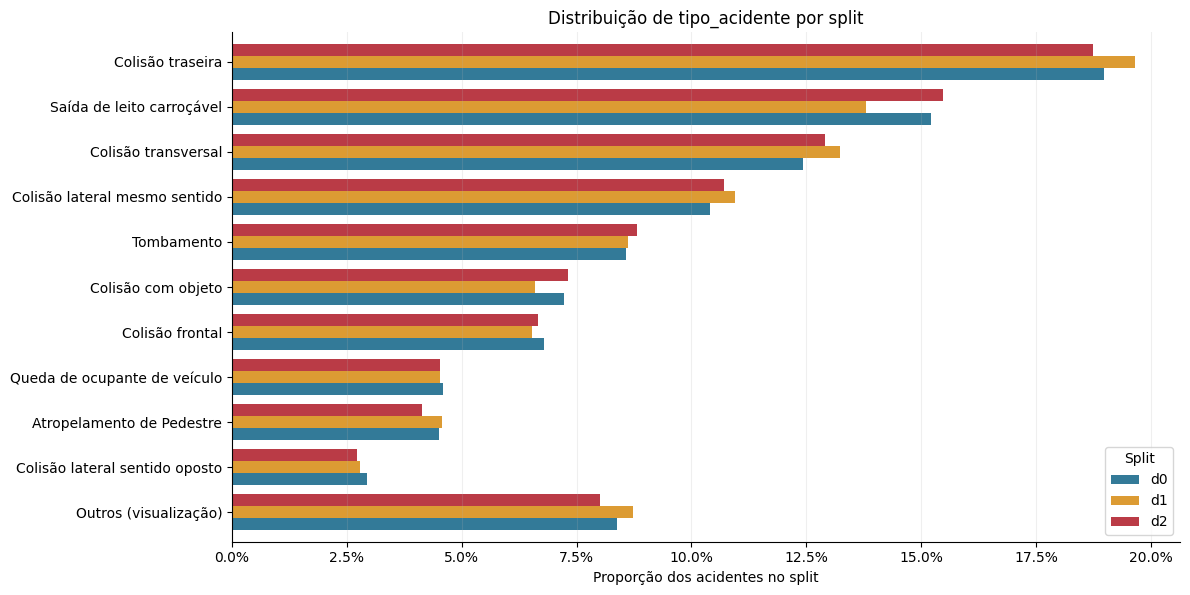


fase_dia: proporções (%) das principais categorias de D0


,d0,d1,d2
fase_dia,,,
Pleno dia,55.69,51.86,57.68
Plena Noite,34.06,37.18,32.70
Anoitecer,5.37,5.91,5.25
Amanhecer,4.88,5.05,4.36


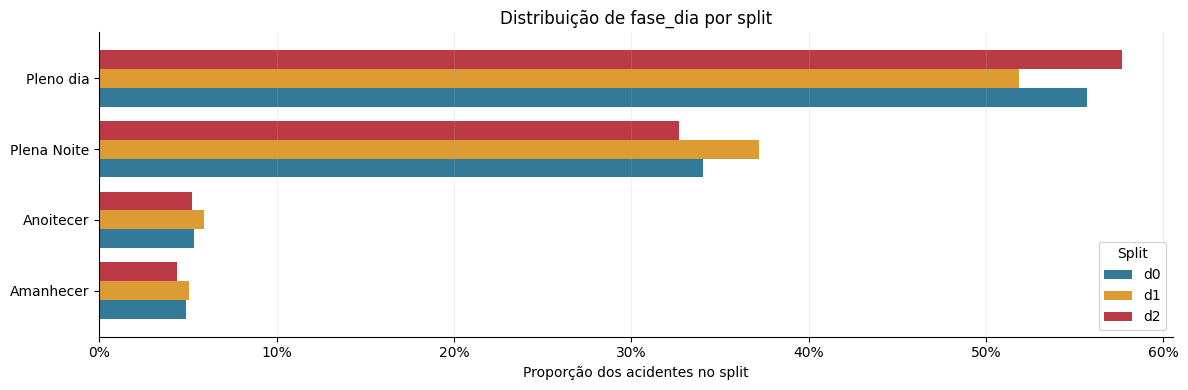


sentido_via: proporções (%) das principais categorias de D0


,d0,d1,d2
sentido_via,,,
Crescente,54.07,53.53,53.81
Decrescente,45.70,46.20,45.94
Não Informado,0.24,0.27,0.25


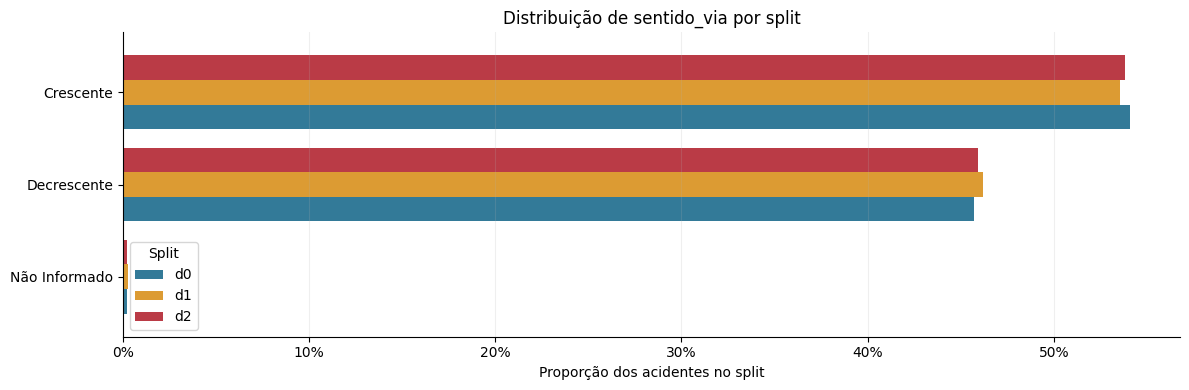


condicao_metereologica: proporções (%) das principais categorias de D0


,d0,d1,d2
condicao_metereologica,,,
Céu Claro,62.27,70.52,58.41
Nublado,15.57,11.86,17.39
Chuva,10.62,6.26,12.60
Sol,5.73,5.31,5.45
Garoa/Chuvisco,3.62,3.01,4.38
Ignorado,1.26,1.32,1.17
Nevoeiro/Neblina,0.78,1.54,0.44
Vento,0.15,0.18,0.15
Granizo,0.00,0.01,0.00


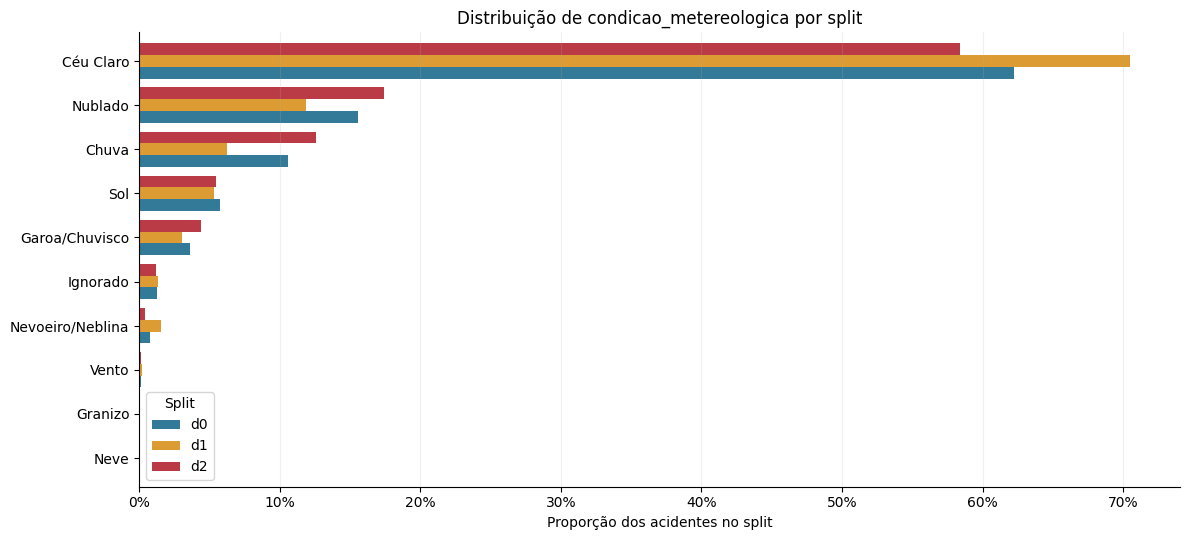


tipo_pista: proporções (%) das principais categorias de D0


,d0,d1,d2
tipo_pista,,,
Simples,48.97,48.57,48.14
Dupla,41.55,41.46,42.33
Múltipla,9.48,9.97,9.54


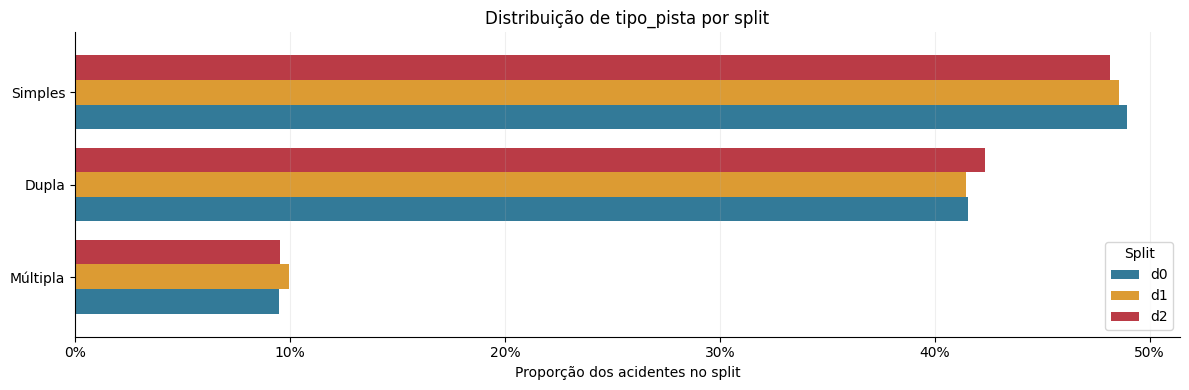


tracado_via: proporções (%) das principais categorias de D0


,d0,d1,d2
tracado_via,,,
Reta,55.65,56.11,54.57
Curva,11.66,11.13,12.31
Reta;Declive,3.02,2.80,2.61
Interseção de Vias,2.55,2.39,2.27
Reta;Aclive,2.28,2.44,2.55
Curva;Declive,2.26,1.71,3.16
Aclive;Reta,2.08,2.07,1.97
Declive;Reta,1.79,1.80,2.31
Declive,1.48,1.26,1.34


Categorias presentes em D1/D2, ausentes em D0 (contagens):


,d0,d1,d2
tracado_via,,,
Aclive;Curva;Interseção de Vias;Viaduto,0,0,1
Aclive;Curva;Interseção de Vias;Viaduto;Rotatória,0,0,1
Aclive;Curva;Ponte,0,1,0
Aclive;Desvio Temporário;Em Obras;Reta,0,0,1
Aclive;Desvio Temporário;Viaduto;Em Obras;Curva,0,0,1
...,...,...,...
Viaduto;Reta;Aclive;Interseção de Vias,0,0,1
Viaduto;Retorno Regulamentado;Interseção de Vias;Em Obras,0,0,1
Viaduto;Retorno Regulamentado;Reta,0,0,1


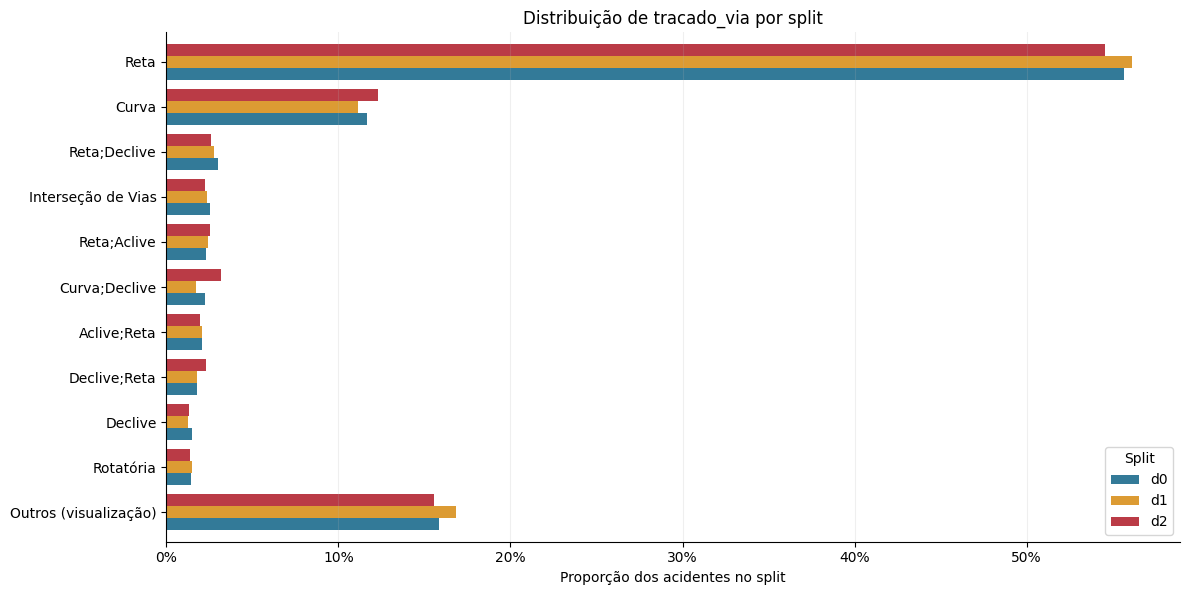


uso_solo: proporções (%) das principais categorias de D0


,d0,d1,d2
uso_solo,,,
Não,57.97,56.05,57.67
Sim,42.03,43.95,42.33


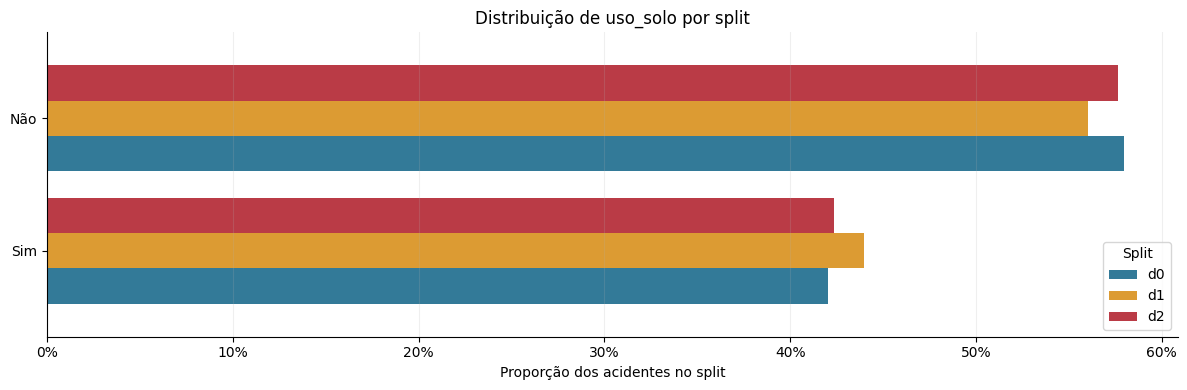

In [6]:
# As categorias de referência vêm de D0 e são reutilizadas nos três períodos.
category_counts = {}
for column in CATEGORICAL + [TARGET]:
    counts = pd.DataFrame({name: part[column].value_counts() for name, part in splits.items()}).fillna(0).astype(int)
    category_counts[column] = counts

for column in CATEGORICAL:
    counts = category_counts[column]
    proportions = counts.div(counts.sum(axis=0), axis=1)
    top = counts["d0"].nlargest(10).index
    print(f"\n{column}: proporções (%) das principais categorias de D0")
    display((proportions.loc[top] * 100).round(2))
    new_categories = counts.loc[(counts.d0 == 0) & ((counts.d1 > 0) | (counts.d2 > 0))]
    if not new_categories.empty:
        print("Categorias presentes em D1/D2, ausentes em D0 (contagens):")
        display(new_categories)
    plotted = proportions.loc[top].copy()
    if len(counts) > len(top):
        plotted.loc["Outros (visualização)"] = proportions.drop(index=top).sum()
    fig, ax = plt.subplots(figsize=(12, max(4, len(plotted) * 0.55)))
    plotted.iloc[::-1].plot.barh(ax=ax, color=list(COLORS.values()), width=0.8)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title=f"Distribuição de {column} por split", xlabel="Proporção dos acidentes no split", ylabel="")
    ax.legend(title="Split")
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"drift_{column}.png", dpi=180, bbox_inches="tight")
    plt.show()

## 5. Qui-quadrado e magnitude das mudanças categóricas

O qui-quadrado testa a associação entre período e categoria; o V de Cramér mede sua magnitude.

O p-valor é omitido quando alguma frequência esperada é menor que 5.

Valores maiores de V indicam maior mudança, sem corte automático.

Referência: [SciPy — chi2_contingency](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html).

In [7]:
chi_rows = []
for column in CATEGORICAL + [TARGET]:
    for recent in ["d1", "d2"]:
        counts = category_counts[column][["d0", recent]]
        counts = counts.loc[counts.sum(axis=1) > 0]
        assert len(counts) >= 2, f"{column} não tem categorias suficientes para o teste."
        statistic, pvalue, dof, expected = chi2_contingency(counts.T.to_numpy(), correction=False)
        applicable = bool((expected >= 5).all())
        proportions = counts.div(counts.sum(axis=0), axis=1)
        delta = (proportions[recent] - proportions["d0"]) * 100
        largest = delta.abs().idxmax()
        chi_rows.append({"variável": column, "comparação": f"D0 → {recent.upper()}",
                         "qui_quadrado": statistic, "graus_liberdade": dof,
                         "V_Cramer": np.sqrt(statistic / counts.to_numpy().sum()),
                         "menor_esperada": expected.min(), "células_esperadas_menor_5": int((expected < 5).sum()),
                         "p_valor": pvalue if applicable else np.nan,
                         "teste": "Aplicável" if applicable else "Não aplicável: categorias raras",
                         "categoria_maior_variação": largest, "variação_pp": delta.loc[largest]})
chi_results = pd.DataFrame(chi_rows)
display(chi_results.style.format({"qui_quadrado": "{:.2f}", "V_Cramer": "{:.4f}",
                                  "menor_esperada": "{:.2f}", "p_valor": "{:.3e}", "variação_pp": "{:+.2f}"}, na_rep="—"))

,variável,comparação,qui_quadrado,graus_liberdade,V_Cramer,menor_esperada,células_esperadas_menor_5,p_valor,teste,categoria_maior_variação,variação_pp
0,dia_semana,D0 → D1,22.53,6,0.0139,3642.22,0,9.684e-04,Aplicável,sexta-feira,+0.80
1,dia_semana,D0 → D2,17.00,6,0.0120,3697.31,0,9.281e-03,Aplicável,sábado,-0.62
2,uf,D0 → D1,72.31,26,0.0248,54.50,0,3.045e-06,Aplicável,MG,-0.97
3,uf,D0 → D2,85.09,26,0.0270,52.75,0,3.369e-08,Aplicável,RJ,+0.71
4,br,D0 → D1,204.45,120,0.0418,0.25,34,—,Não aplicável: categorias raras,101,-0.45
5,br,D0 → D2,192.28,119,0.0405,0.25,32,—,Não aplicável: categorias raras,230,+0.41
6,causa_acidente,D0 → D1,708.54,74,0.0778,1.00,11,—,Não aplicável: categorias raras,Ausência de reação do condutor,+1.01
7,causa_acidente,D0 → D2,460.08,74,0.0627,1.75,10,—,Não aplicável: categorias raras,Ausência de reação do condutor,+0.82
8,tipo_acidente,D0 → D1,107.16,16,0.0302,2.00,1,—,Não aplicável: categorias raras,Saída de leito carroçável,-1.41
9,tipo_acidente,D0 → D2,37.06,16,0.0178,1.25,2,—,Não aplicável: categorias raras,Colisão transversal,+0.46


## 6. Distribuição do alvo

As proporções das três classes são comparadas entre D0, D1 e D2.

classificacao_acidente,Com Vítimas Feridas,Sem Vítimas,Com Vítimas Fatais
d0,67437,14189,6212
d1,22293,4813,2173
d2,22692,4534,2054


classificacao_acidente,Com Vítimas Feridas,Sem Vítimas,Com Vítimas Fatais
d0,76.774,16.154,7.072
d1,76.140,16.438,7.422
d2,77.500,15.485,7.015


,variável,comparação,qui_quadrado,graus_liberdade,V_Cramer,menor_esperada,células_esperadas_menor_5,p_valor,teste,categoria_maior_variação,variação_pp
22,classificacao_acidente,D0 → D1,5.999807,2,0.0072,2096.232101,0,4.979e-02,Aplicável,Com Vítimas Feridas,-0.63
23,classificacao_acidente,D0 → D2,7.745355,2,0.0081,2066.535289,0,2.080e-02,Aplicável,Com Vítimas Feridas,+0.73


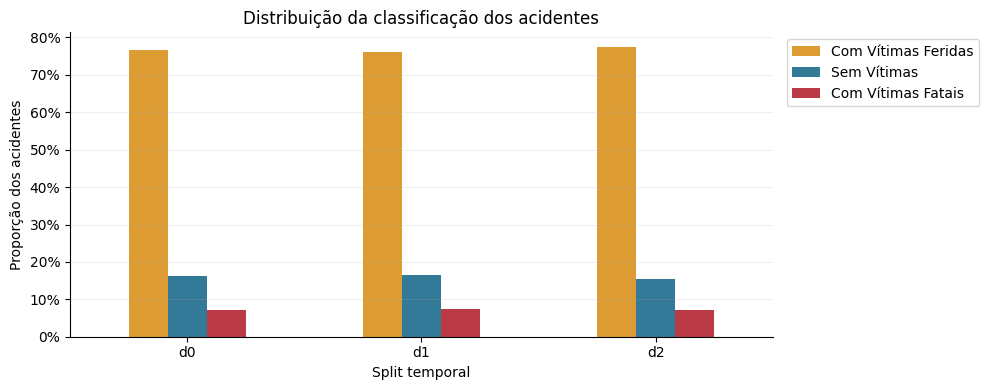

In [8]:
target_counts = category_counts[TARGET].T
target_proportions = target_counts.div(target_counts.sum(axis=1), axis=0)
display(target_counts)
display((target_proportions * 100).round(3))
display(chi_results.loc[chi_results["variável"].eq(TARGET)].style.format(
    {"V_Cramer": "{:.4f}", "p_valor": "{:.3e}", "variação_pp": "{:+.2f}"}))

class_colors = {"Com Vítimas Fatais": "#ba3b46", "Com Vítimas Feridas": "#dc9b33", "Sem Vítimas": "#337a98"}
fig, ax = plt.subplots(figsize=(10, 4))
target_proportions.plot.bar(ax=ax, color=[class_colors[c] for c in target_proportions.columns], rot=0)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(title="Distribuição da classificação dos acidentes", xlabel="Split temporal", ylabel="Proporção dos acidentes")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "drift_target.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Síntese do drift

As tabelas reúnem as magnitudes D0→D1 e D0→D2. KS e V de Cramér devem ser analisados separadamente.

Esta análise não altera as variáveis nem o pipeline.

Numéricas — distância KS


comparação,D0 → D1,D0 → D2
variável,,
hora,0.0137,0.0091
mes,0.3759,0.5442
km,0.0109,0.0131
latitude,0.0172,0.0101
longitude,0.0134,0.0198
veiculos,0.0200,0.0084


Categóricas e alvo — V de Cramér descritivo


comparação,D0 → D1,D0 → D2
variável,,
dia_semana,0.0139,0.0120
uf,0.0248,0.0270
br,0.0418,0.0405
causa_acidente,0.0778,0.0627
tipo_acidente,0.0302,0.0178
fase_dia,0.0337,0.0185
sentido_via,0.0053,0.0025
condicao_metereologica,0.0942,0.0465
tipo_pista,0.0074,0.0073


Maiores alterações de proporção por comparação


,variável,comparação,categoria_maior_variação,variação_pp,teste
0,dia_semana,D0 → D1,sexta-feira,0.801,Aplicável
1,dia_semana,D0 → D2,sábado,-0.624,Aplicável
2,uf,D0 → D1,MG,-0.972,Aplicável
3,uf,D0 → D2,RJ,0.707,Aplicável
4,br,D0 → D1,101,-0.449,Não aplicável: categorias raras
5,br,D0 → D2,230,0.409,Não aplicável: categorias raras
6,causa_acidente,D0 → D1,Ausência de reação do condutor,1.005,Não aplicável: categorias raras
7,causa_acidente,D0 → D2,Ausência de reação do condutor,0.820,Não aplicável: categorias raras
8,tipo_acidente,D0 → D1,Saída de leito carroçável,-1.409,Não aplicável: categorias raras
9,tipo_acidente,D0 → D2,Colisão transversal,0.464,Não aplicável: categorias raras


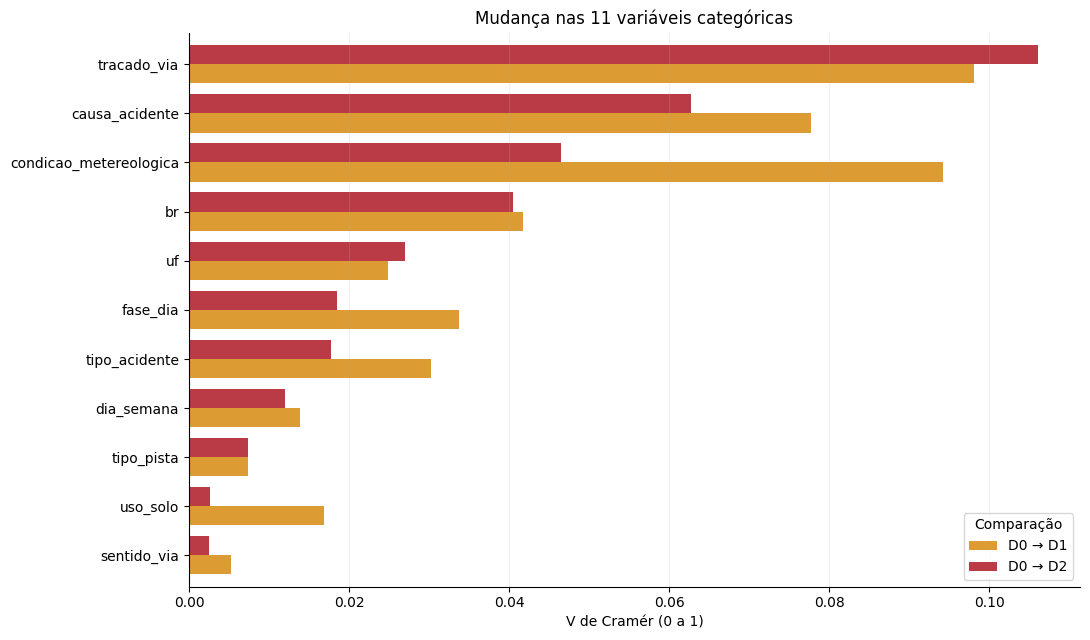

Figuras salvas em: d:\Workspace\ws-uem\acidentes-rodoviarios-ml\outputs\figures


In [9]:
print("Numéricas — distância KS")
numeric_summary = ks_results.pivot(index="variável", columns="comparação", values="D_KS").reindex(NUMERIC)
display(numeric_summary.round(4))

print("Categóricas e alvo — V de Cramér descritivo")
categorical_summary = chi_results.pivot(index="variável", columns="comparação", values="V_Cramer")
categorical_summary = categorical_summary.reindex(CATEGORICAL + [TARGET])
display(categorical_summary.round(4))

print("Maiores alterações de proporção por comparação")
display(chi_results[["variável", "comparação", "categoria_maior_variação", "variação_pp", "teste"]].round(3))

# Resumo visual das 11 variáveis categóricas usadas pelo modelo.
cat_plot = categorical_summary.loc[CATEGORICAL].copy()
cat_plot = cat_plot.sort_values("D0 → D2", ascending=True)
fig, ax = plt.subplots(figsize=(11, 6.5))
cat_plot.plot.barh(ax=ax, color=[COLORS["d1"], COLORS["d2"]], width=0.78)
ax.set(
    title="Mudança nas 11 variáveis categóricas",
    xlabel="V de Cramér (0 a 1)",
    ylabel="",
)
ax.grid(axis="x", alpha=0.2)
ax.legend(title="Comparação")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "drift_categorical.png", dpi=180, bbox_inches="tight")
plt.show()

print("Figuras salvas em:", FIGURE_DIR)


### Critérios de interpretação

A leitura combina magnitude e visualização:

- **Numéricas:** distância KS;
- **Categóricas:** V de Cramér;
- **Alvo:** proporções das classes e V de Cramér;
- **Concept drift:** exige evidência de mudança em P(y | X).


## 8. Limitações e interpretação

- `mes` mistura drift e sazonalidade;
- os dados representam registros da PRF, não exposição ao tráfego;
- categorias raras, empates e dependência temporal limitam os p-valores;
- os testes não demonstram concept drift.